<a href="https://colab.research.google.com/github/hansi-2000/HR-Project_ML/blob/main/EMP_Attrition_rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
## IMPORT LIBRARIES ##

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Import the required function for preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Import train and test split function
from sklearn.model_selection import train_test_split

# Import Classifiers to be used
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Import packages to calculate performance of the models
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, roc_auc_score

# To save the model import pickle
import pickle



In [8]:
import pandas as pd

# Train dataset
train_url = 'https://drive.google.com/uc?export=download&id=1IIJ2CtGea8zccK0nJxVhbrXJgx3UdCA1'
train = pd.read_csv(train_url)

# Test dataset
test_url = 'https://drive.google.com/uc?export=download&id=1bXVZqMffCWcBUqXgrQbeGulYObj126nH'
test = pd.read_csv(test_url)

# Check if the data is loaded correctly
print(train.head())
print(test.head())


   Employee ID  Age  Gender  Years at Company    Job Role  Monthly Income  \
0         8410   31    Male                19   Education            5390   
1        64756   59  Female                 4       Media            5534   
2        30257   24  Female                10  Healthcare            8159   
3        65791   36  Female                 7   Education            3989   
4        65026   56    Male                41   Education            4821   

  Work-Life Balance Job Satisfaction Performance Rating  Number of Promotions  \
0         Excellent           Medium            Average                     2   
1              Poor             High                Low                     3   
2              Good             High                Low                     0   
3              Good             High               High                     1   
4              Fair        Very High            Average                     0   

   ... Marital Status  Number of Dependents Job Le

In [ ]:
emp_data = pd.concat([train, test], ignore_index=True)

emp_data.info()

emp_data.nunique()

emp_data.isnull().sum()
print()

print("Duplicates: ",emp_data.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74498 entries, 0 to 74497
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               74498 non-null  int64 
 1   Age                       74498 non-null  int64 
 2   Gender                    74498 non-null  object
 3   Years at Company          74498 non-null  int64 
 4   Job Role                  74498 non-null  object
 5   Monthly Income            74498 non-null  int64 
 6   Work-Life Balance         74498 non-null  object
 7   Job Satisfaction          74498 non-null  object
 8   Performance Rating        74498 non-null  object
 9   Number of Promotions      74498 non-null  int64 
 10  Overtime                  74498 non-null  object
 11  Distance from Home        74498 non-null  int64 
 12  Education Level           74498 non-null  object
 13  Marital Status            74498 non-null  object
 14  Number of Dependents  

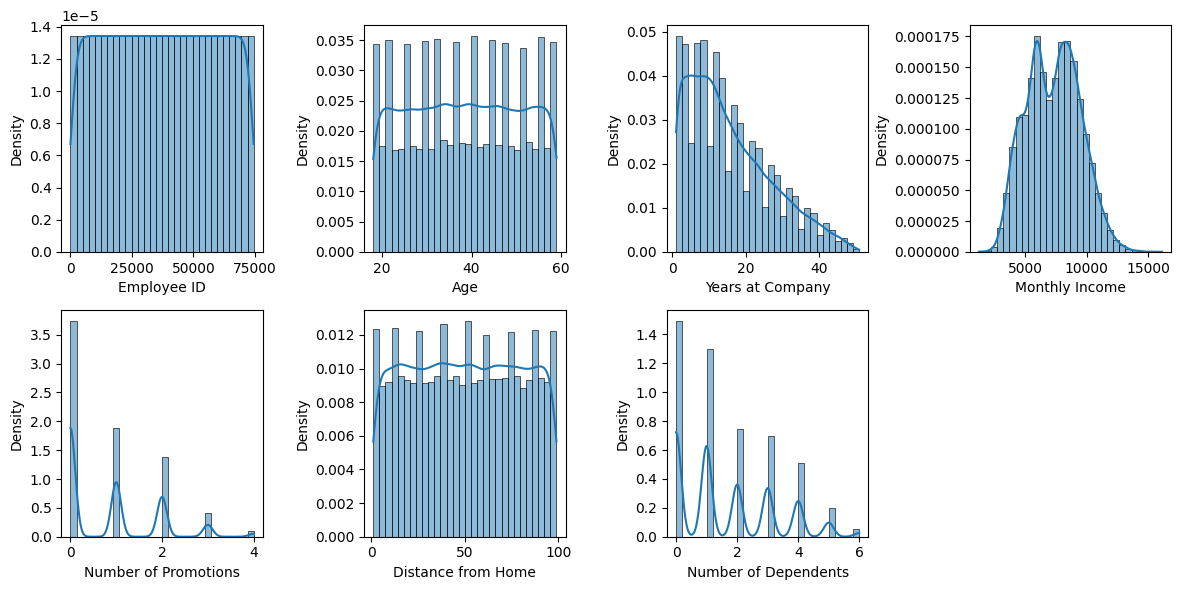

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

emp_eda = emp_data.copy()

# Assuming emp_eda is already defined and contains numeric columns
num_cols_eda = [n for n in emp_eda.columns if emp_eda[n].dtypes != 'O']

# Create a 2x4 grid of subplots (8 subplots total, we'll use 7)
fig, ax = plt.subplots(2, 4, figsize=(12, 6))
ax = ax.flatten()

# Loop over the first 7 numerical columns and create a histogram for each
for i, col in enumerate(num_cols_eda[:7]):  # Limit to 7 columns
    sns.histplot(emp_eda[col], kde=True, stat='density', bins=30, ax=ax[i])

# Hide the 8th subplot (since we only need 7 plots)
ax[7].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


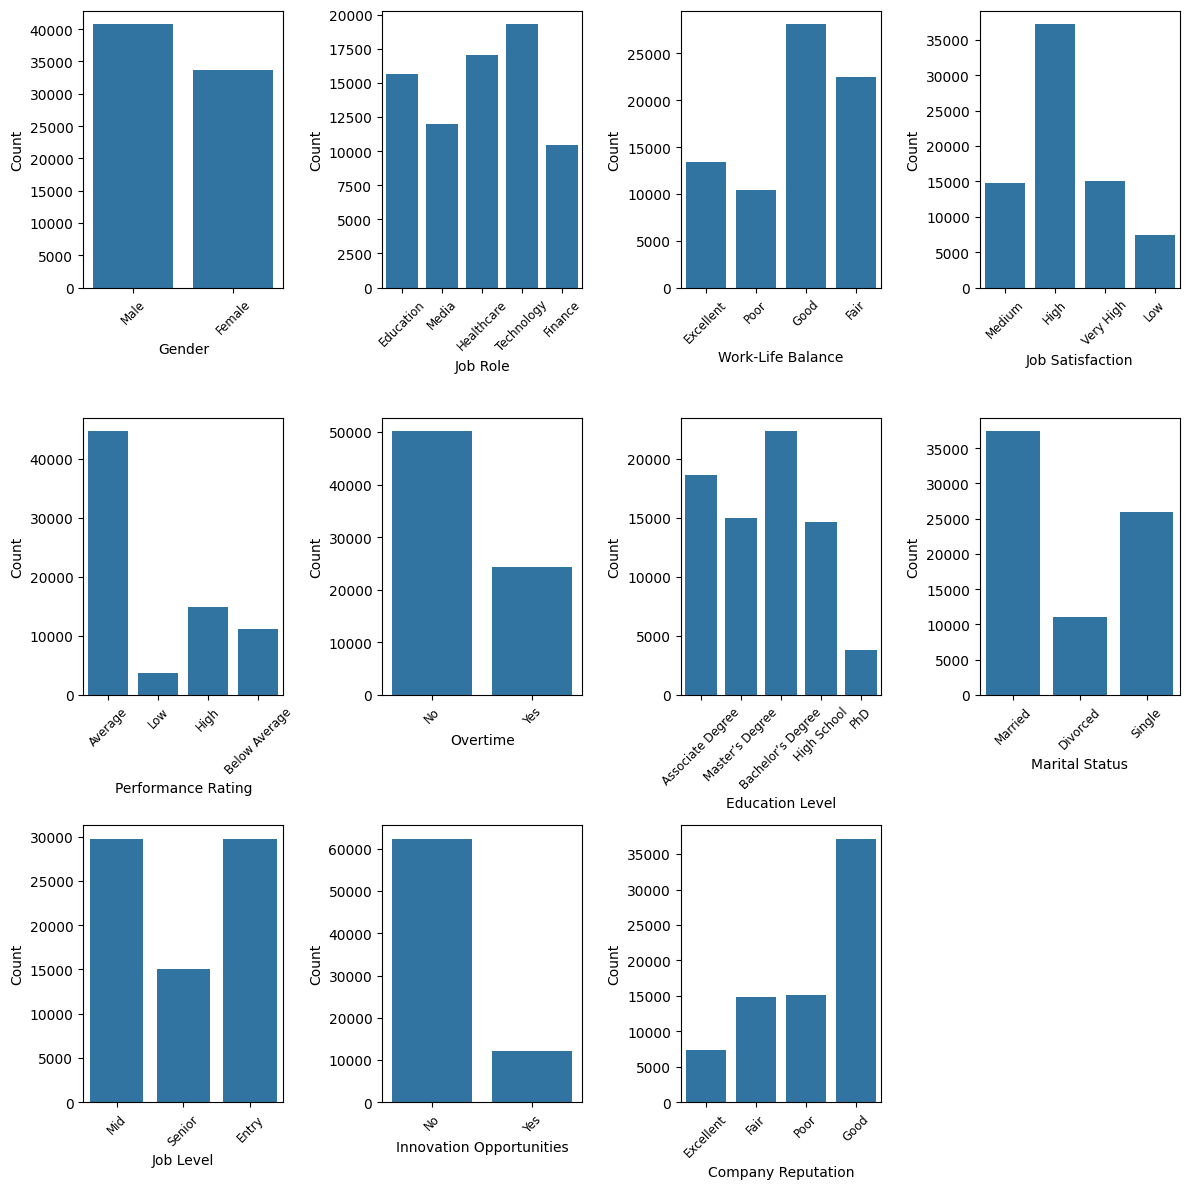

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming emp_eda is already defined and contains categorical columns
cat_cols_eda = [c for c in emp_eda.columns if emp_eda[c].dtypes == 'O']

# Create a 3x4 grid of subplots (12 subplots total)
fig, ax = plt.subplots(3, 4, figsize=(12, 12))
ax = ax.flatten()

# Loop over the first 11 categorical columns and create a countplot for each
for i, col in enumerate(cat_cols_eda[:11]):  # Limit to 11 columns
    sns.countplot(x=col, data=emp_eda, ax=ax[i])
    ax[i].set_ylabel('Count')
    ax[i].tick_params(axis='x', rotation=45, labelsize=8.5)

# Hide the 12th subplot (since we only need 11 plots)
ax[11].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


In [15]:
import pandas as pd

# Train dataset
train_url = 'https://drive.google.com/uc?export=download&id=1IIJ2CtGea8zccK0nJxVhbrXJgx3UdCA1'
train = pd.read_csv(train_url)

# Test dataset
test_url = 'https://drive.google.com/uc?export=download&id=1bXVZqMffCWcBUqXgrQbeGulYObj126nH'
test = pd.read_csv(test_url)

In [16]:
# emp_data.head()
#print(emp_data.columns)

ordinal_mappings = {
    'Work-Life Balance': {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4},
    'Company Reputation': {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4},
    'Job Satisfaction': {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4},
    'Performance Rating': {'Low': 1, 'Below Average': 2, 'Average': 3, 'High': 4},
    'Education Level': {'High School': 1, 'Associate Degree': 2, 'Bachelor’s Degree': 3, 'Master’s Degree': 4, 'PhD': 5},
    'Job Level': {'Entry': 1, 'Mid': 2, 'Senior': 3},
    'Company Reputation': {'Very Poor': 0, 'Poor': 1, 'Good': 2, 'Excellent': 3},
    'Employee Recognition': {'Very Low': 0, 'Low': 1, 'Medium': 2, 'High': 3}
}

for col, mapping in ordinal_mappings.items():
    train[col] = train[col].map(mapping)
    test[col] = test[col].map(mapping)


In [17]:
# print("Unique values in Gender column:", emp_data['Gender'].unique())
binary_columns = ['Innovation Opportunities', 'Overtime', 'Attrition', 'Remote Work', 'Leadership Opportunities']

binary_mapping = {'No': 0, 'Yes': 1, 'Stayed':1, 'Left':0}

for col in binary_columns:
    train[col] = train[col].map(binary_mapping)
    test[col] = test[col].map(binary_mapping)

tran_1 = train.copy()
test_1 = test.copy()

train_df = train.drop(columns=['Job Role', 'Marital Status','Gender'])
test_df = test.drop(columns=['Job Role', 'Marital Status','Gender'])

train = train.drop(columns=['Job Role', 'Marital Status','Gender'])
test = test.drop(columns=['Job Role', 'Marital Status','Gender'])

train_df.head(10)



,Employee ID,Age,Years at Company,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Number of Dependents,Job Level,Employee Recognition,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Attrition
0,8410,31,19,5390,4,2,3,2,0,22,2,0,2,2.0,89,0,0,0,3.0,1
1,64756,59,4,5534,1,3,1,3,0,21,4,3,2,1.0,21,0,0,0,NaN,1
2,30257,24,10,8159,3,3,1,0,0,11,3,3,2,1.0,74,0,0,0,1.0,1
3,65791,36,7,3989,3,3,4,1,0,27,1,2,2,2.0,50,1,0,0,2.0,1
4,65026,56,41,4821,2,4,3,0,1,71,1,0,3,2.0,68,0,0,0,NaN,1
5,24368,38,3,9977,2,3,2,3,0,37,3,0,2,3.0,47,0,0,1,NaN,0
6,64970,47,23,3681,2,3,4,1,1,75,1,3,1,2.0,93,0,0,0,2.0,0
7,36999,48,16,11223,4,4,4,2,0,5,4,4,1,1.0,88,0,0,0,3.0,1
8,32714,57,44,3773,3,2,4,1,1,39,1,4,1,2.0,75,0,0,0,NaN,1
9,15944,24,1,7319,1,3,3,1,1,57,5,4,1,1.0,45,0,0,1,2.0,0


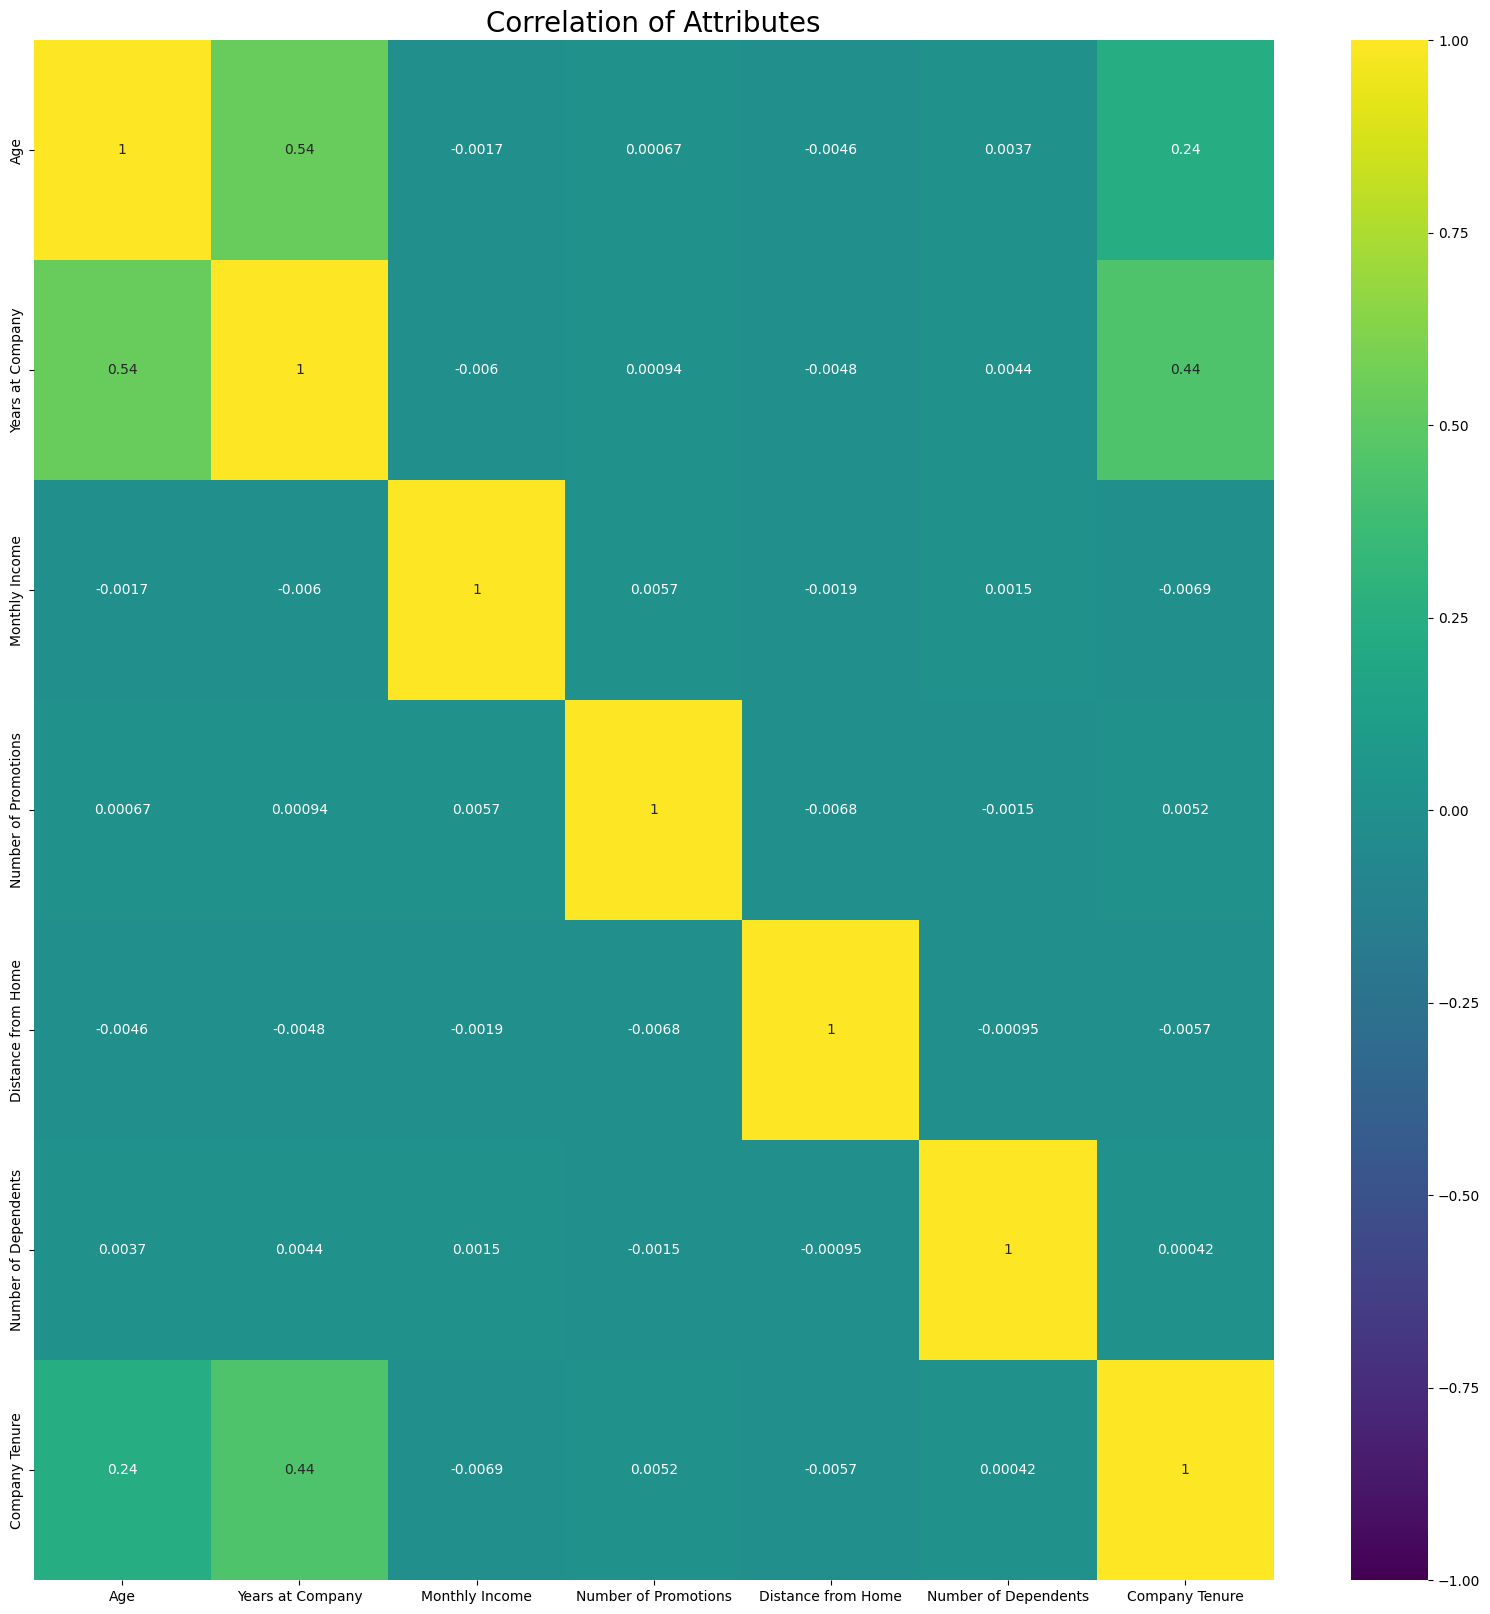

In [ ]:
emp_data = emp_data.drop(columns=['Employee ID'])

num_cols = [n for n in emp_data.columns if emp_data[n].dtypes!='O']
colormap = plt.cm.viridis
plt.figure(figsize=(20,20))
plt.title('Correlation of Attributes', size=20)
ax = sns.heatmap(emp_data[num_cols].corr(), cmap=colormap, annot=True, vmin=-1, vmax=1)
plt.show()

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

train = train.sample(frac=1, random_state=42).reset_index(drop=True)
test = test.sample(frac=1, random_state=42).reset_index(drop=True)

# Step 2: Separate features and target variable for training
X_train = train_df.drop(columns=['Attrition'])  # Assuming 'Attrition' is the target column
y_train = train_df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)  # Convert 'Yes'/'No' to 1/0

# Prepare the test data
X_test = test_df.drop(columns=['Attrition'])
y_test = test_df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# Step 3: Define the hyperparameter grid for RandomForest
param_grid = {
    'n_estimators': [50, 100],
    'min_samples_split': [10, 20],          # Increased from lower values
    'min_samples_leaf': [4, 8],             # Increased from lower values
    'max_depth': [10, 20, None],            # Limit tree depth to control complexity
    'class_weight': ['balanced_subsample']
}

# Step 4: Perform GridSearchCV to find the best parameters
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

# Fit the model to the training data
grid_search.fit(X_train, y_train)

# Step 5: Train the model with the best parameters
best_rf = grid_search.best_estimator_

# Step 6: Evaluate the model on the test data
y_pred = best_rf.predict(X_test)
print("Best Hyperparameters found by GridSearchCV:", grid_search.best_params_)
print("Accuracy on test set:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Hyperparameters found by GridSearchCV: {'class_weight': 'balanced_subsample', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}
Accuracy on test set: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     14900

    accuracy                           1.00     14900
   macro avg       1.00      1.00      1.00     14900
weighted avg       1.00      1.00      1.00     14900



In [9]:
# Check for any remaining categorical/object type columns
remaining_categoricals = train.select_dtypes(include=['object']).columns
print("Remaining categorical columns (if any):", remaining_categoricals.tolist())


Remaining categorical columns (if any): ['Job Role']


Training Accuracy: 0.7392971858670119
Testing Accuracy: 0.7195749440715884

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.72      0.71      8570
           1       0.73      0.72      0.73      9310

    accuracy                           0.72     17880
   macro avg       0.72      0.72      0.72     17880
weighted avg       0.72      0.72      0.72     17880



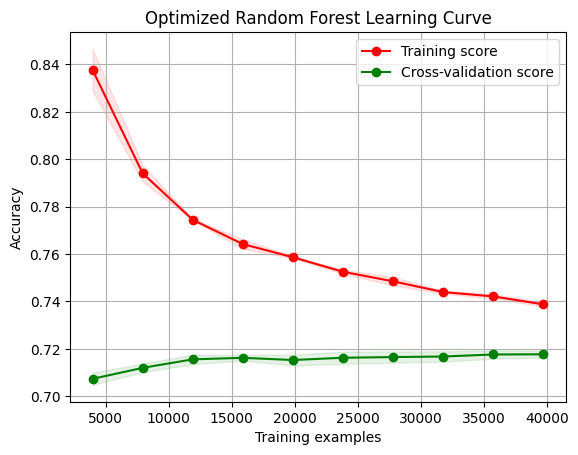

In [21]:
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import learning_curve, train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Shuffle the entire dataset and reset the index
train = train.sample(frac=1, random_state=42).reset_index(drop=True)

# Split the data into features and target
X = train.drop(columns=['Attrition'])
y = train['Attrition']

# Scale features for improved performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, shuffle=True)

# Random Forest with optimized hyperparameters using RandomizedSearchCV
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 7, 9, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}
rf = RandomForestClassifier(random_state=42)
search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=20, cv=3, scoring='accuracy', random_state=42)
search.fit(X_train, y_train)

# Best model
rf_optimized = search.best_estimator_

# Evaluate model performance
y_train_pred = rf_optimized.predict(X_train)
y_test_pred = rf_optimized.predict(X_test)
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred)}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred)}")
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

# Generating learning curve
train_sizes, train_scores, test_scores = learning_curve(
    rf_optimized, X_scaled, y, cv=3, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate means and standard deviations
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure()
plt.title("Optimized Random Forest Learning Curve")
plt.xlabel("Training examples")
plt.ylabel("Accuracy")
plt.grid()

# Plot shaded areas for standard deviation
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")

# Plot the mean scores
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

plt.legend(loc="best")
plt.show()


In [ ]:
!pip install catboost
!pip install scikit-optimize

# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import StackingClassifier
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import numpy as np
import pandas as pd

# Assuming 'train' and 'test' DataFrames are loaded and preprocessed

# Define features (X) and target (y)
X = train.drop(columns=['Attrition'])
y = train['Attrition']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Shuffle data before training
train = train.sample(frac=1, random_state=42).reset_index(drop=True)
test = test.sample(frac=1, random_state=42).reset_index(drop=True)

### Step 1: Bayesian Optimization for Each Base Model

# Define and optimize each model

# 1. Random Forest Optimization
# Updated parameter space for Bayesian Optimization without 'auto' for max_features
rf_params = {
    'n_estimators': Integer(50, 500),
    'max_depth': Integer(3, 20),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 10),
    'max_features': ['sqrt', 'log2', None]  # Updated options for max_features
}


rf_bo = BayesSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    n_iter=20,  # Adjust n_iter for a more thorough search if needed
    scoring='accuracy',
    cv=5,
    random_state=42
)
rf_bo.fit(X_train, y_train)
best_rf = rf_bo.best_estimator_

# 2. CatBoost Optimization
catboost_params = {
    'iterations': Integer(100, 1000),
    'depth': Integer(4, 10),
    'learning_rate': Real(0.01, 0.3, 'log-uniform'),
    'l2_leaf_reg': Real(1, 10),
}

catboost_bo = BayesSearchCV(
    CatBoostClassifier(verbose=0, random_state=42),
    catboost_params,
    n_iter=20,
    scoring='accuracy',
    cv=5,
    random_state=42
)
catboost_bo.fit(X_train, y_train)
best_catboost = catboost_bo.best_estimator_

# 3. LightGBM Optimization
lgb_params = {
    'n_estimators': Integer(50, 200),
    'max_depth': Integer(4, 20),
    'learning_rate': Real(0.01, 0.3, 'log-uniform'),
    'num_leaves': Integer(10, 50),
}

lgb_bo = BayesSearchCV(
    lgb.LGBMClassifier(random_state=42),
    lgb_params,
    n_iter=20,
    scoring='accuracy',
    cv=5,
    random_state=42
)
lgb_bo.fit(X_train, y_train)
best_lgb = lgb_bo.best_estimator_

### Step 2: Set Up Stacking Classifier with Meta-Learner

# Define base models for stacking
estimators = [
    ('rf', best_rf),
    ('catboost', best_catboost),
    ('lgb', best_lgb)
]

# Initialize the stacking classifier with logistic regression as the meta-learner
from sklearn.linear_model import LogisticRegression
stacked_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=42),
    cv=5
)

# Train the stacked model
stacked_clf.fit(X_train, y_train)

### Step 3: Evaluate the Stacked Model

# Predict on the test set
y_pred = stacked_clf.predict(X_test)

# Print accuracy and classification report
print("Stacked Model Accuracy on Test Set:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


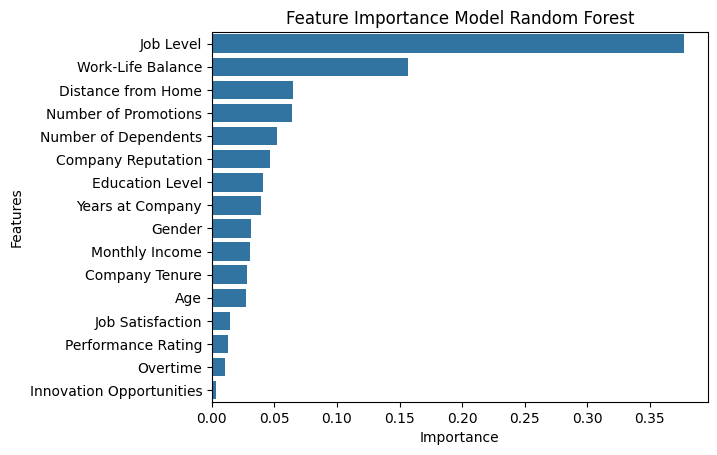

In [33]:
#Extract feature importances
imp = pd.DataFrame()
imp['Features'] = X.columns
imp['Importance'] = rf.feature_importances_
imp = imp.sort_values(by='Importance', ascending=False)

#Plot the feature importances
sns.barplot(imp, y='Features', x='Importance')
plt.title("Feature Importance Model Random Forest")
plt.show()

Best RF Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.68      0.68      8521
           1       0.71      0.71      0.71      9359

    accuracy                           0.70     17880
   macro avg       0.70      0.70      0.70     17880
weighted avg       0.70      0.70      0.70     17880



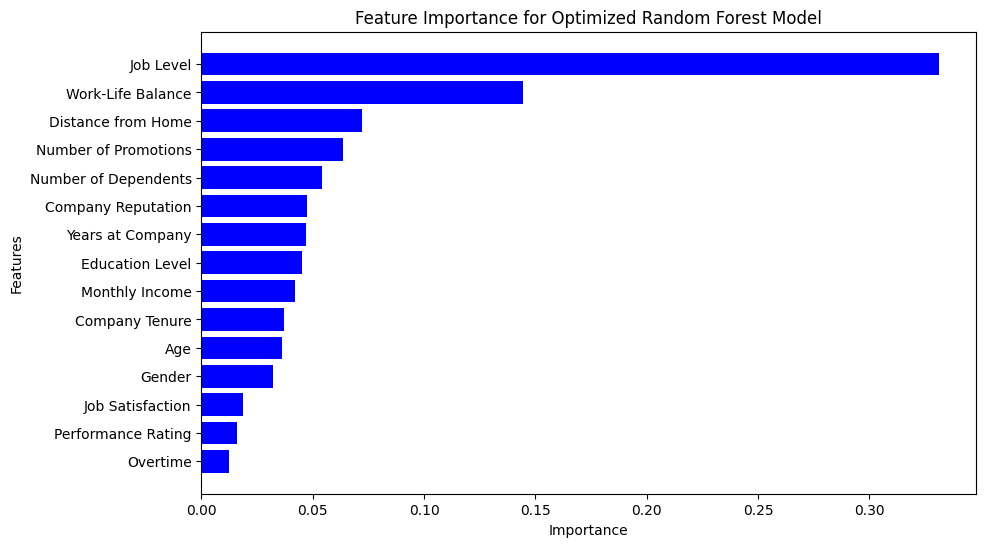

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 21887, number of negative: 19831
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003312 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Number of data points in the train set: 41718, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524642 -> initscore=0.098646
[LightGBM] [Info] Start training from score 0.098646
LightGBM Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.69      0.69      8521
           1       0.71      0.71      0.71      9359

    accuracy                           0.70     17880
   macro avg       0.70      0.70      0.70     17880
weighted avg       0.70      0.70      0.70     17880



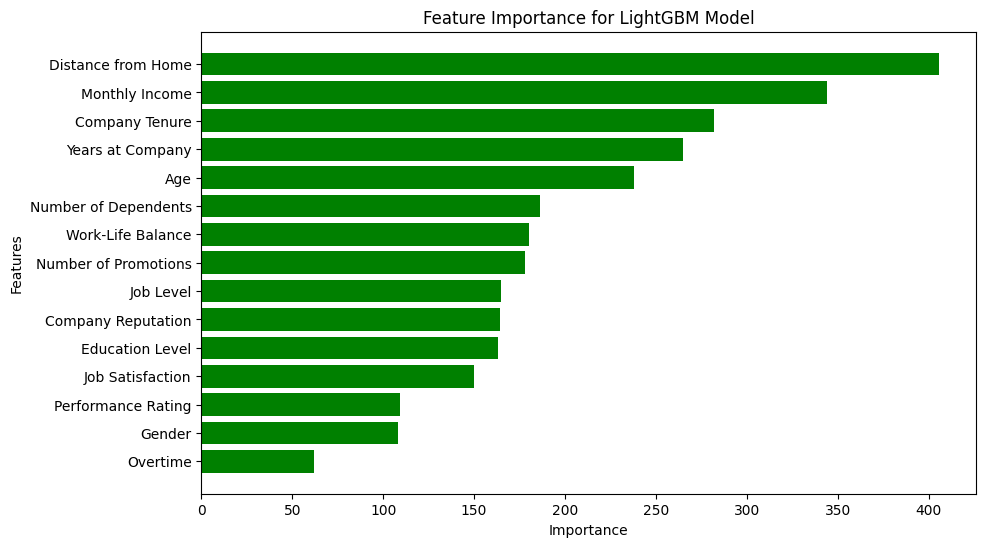

In [5]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt

# Data preparation
train = train.drop(columns=['Job Role', 'Marital Status','Employee ID','Innovation Opportunities'])
test = test.drop(columns=['Job Role', 'Marital Status','Employee ID','Innovation Opportunities'])
X = train.drop(columns=['Attrition'])
y = train['Attrition']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Grid search for Random Forest hyperparameter tuning
param_grid_rf = {
    'max_depth': [8, 10, 12, 15],
    'n_estimators': [100, 200, 300],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

# Evaluate Random Forest
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
print("Best RF Parameters:", grid_search_rf.best_params_)
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

# Feature importance plot for tuned Random Forest
feature_importances_rf = best_rf.feature_importances_
indices_rf = np.argsort(feature_importances_rf)[::-1]
features_rf = X.columns

plt.figure(figsize=(10, 6))
plt.title("Feature Importance for Optimized Random Forest Model")
plt.barh(features_rf[indices_rf], feature_importances_rf[indices_rf], color="b", align="center")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

# LightGBM model as an alternative
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
print("LightGBM Classification Report:\n", classification_report(y_test, y_pred_lgb))

# Feature importance for LightGBM
feature_importances_lgb = lgb_model.feature_importances_
indices_lgb = np.argsort(feature_importances_lgb)[::-1]
features_lgb = X.columns

plt.figure(figsize=(10, 6))
plt.title("Feature Importance for LightGBM Model")
plt.barh(features_lgb[indices_lgb], feature_importances_lgb[indices_lgb], color="g", align="center")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
!pip install shap

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import lightgbm as lgb
import shap
import numpy as np
import matplotlib.pyplot as plt

# Data preparation
train = train.drop(columns=['Job Role', 'Marital Status', 'Employee ID'])

X = train.drop(columns=['Attrition'])
y = train['Attrition']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Grid search for Random Forest hyperparameter tuning
param_grid_rf = {
    'max_depth': [8, 10, 12, 15],
    'n_estimators': [100, 200, 300],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

# Evaluate Random Forest
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
print("Best RF Parameters:", grid_search_rf.best_params_)
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

# LightGBM model as an alternative
param_grid_lgb = {
    'num_leaves': [31, 50, 100],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [-1, 10, 20],
    'n_estimators': [100, 200, 300]
}
lgb_model = lgb.LGBMClassifier(is_unbalance=True, random_state=42)
grid_search_lgb = GridSearchCV(estimator=lgb_model, param_grid=param_grid_lgb, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_lgb.fit(X_train, y_train)

# Evaluate the best LightGBM model
best_lgb = grid_search_lgb.best_estimator_
y_pred_lgb = best_lgb.predict(X_test)
print("Best LightGBM Parameters:", grid_search_lgb.best_params_)
print("Optimized LightGBM Classification Report:\n", classification_report(y_test, y_pred_lgb))

# SHAP analysis for LightGBM
explainer = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(X_test)

# SHAP summary plot (Bar plot for overall feature importance)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[1], X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (LightGBM)")
plt.show()

# SHAP detailed summary plot (each dot represents SHAP value for each instance and feature)
shap.summary_plot(shap_values[1], X_test)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2509, number of negative: 2258
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000617 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 617
[LightGBM] [Info] Number of data points in the train set: 4767, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.526327 -> initscore=0.105405
[LightGBM] [Info] Start training from score 0.105405
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 5035, number of negative: 4500
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002999 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 621
[LightGBM] [Info] Number

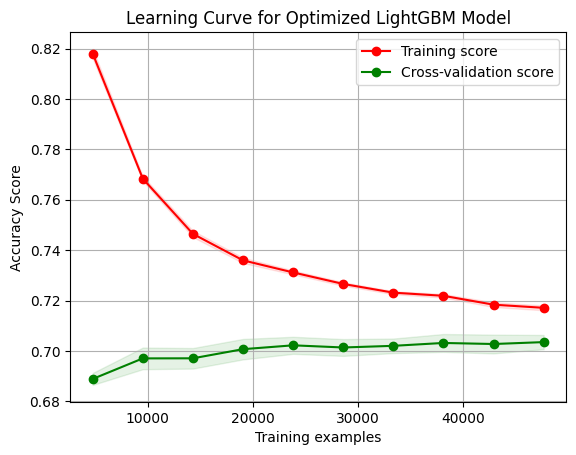

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 21898, number of negative: 19820
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003424 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 625
[LightGBM] [Info] Number of data points in the train set: 41718, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524905 -> initscore=0.099704
[LightGBM] [Info] Start training from score 0.099704
Training accuracy = 0.7187784649312048
Testing accuracy = 0.7008389261744966


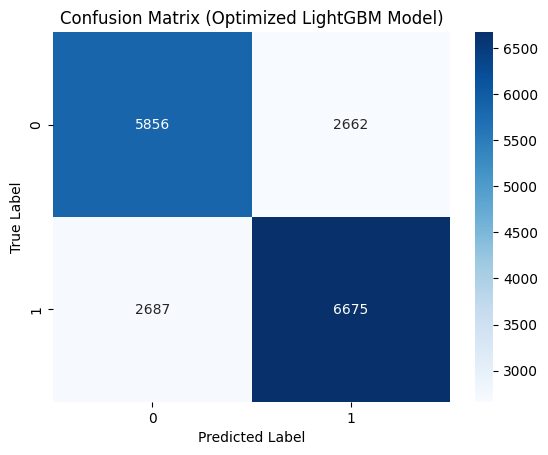

              precision    recall  f1-score   support

           0       0.69      0.69      0.69      8518
           1       0.71      0.71      0.71      9362

    accuracy                           0.70     17880
   macro avg       0.70      0.70      0.70     17880
weighted avg       0.70      0.70      0.70     17880



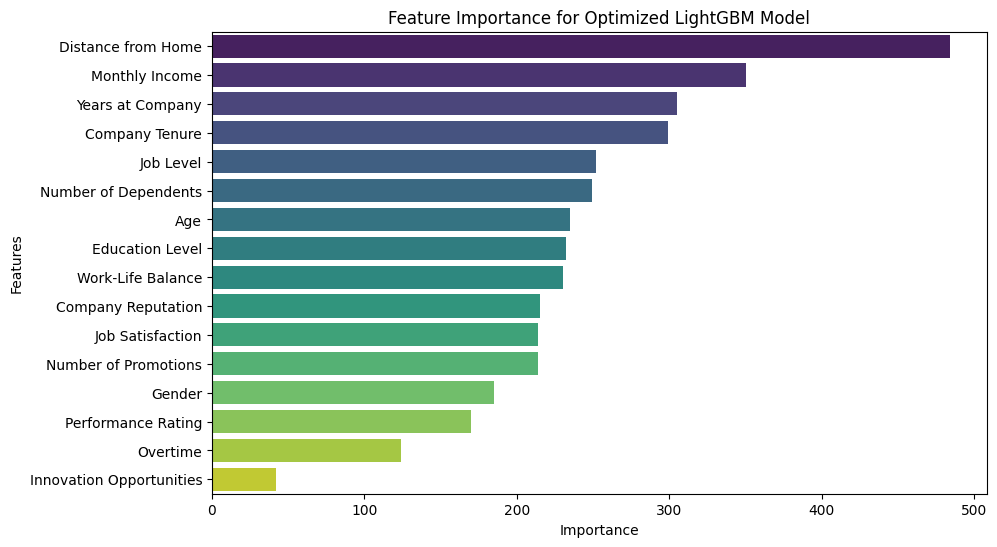

Low-importance features to consider removing: []


In [ ]:
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data preparation
X = train.drop(columns=['Attrition'])
y = train['Attrition']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the LightGBM model with optimized parameters
light_gbm = lgb.LGBMClassifier(
    boosting_type='gbdt',
    num_leaves=20,
    learning_rate=0.05,
    n_estimators=200,
    max_depth=15,
    min_child_samples=30,
    colsample_bytree=0.7,
    subsample=0.7
)

# Generating learning curves
train_sizes, train_scores, test_scores = learning_curve(
    light_gbm, X, y, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculating mean and standard deviation for training and cross-validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plotting the learning curve
plt.figure()
plt.title("Learning Curve for Optimized LightGBM Model")
plt.xlabel("Training examples")
plt.ylabel("Accuracy Score")
plt.grid()
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.legend(loc="best")
plt.show()

# Fitting the optimized LightGBM model on the training set
light_gbm.fit(X_train, y_train)

# Calculating accuracy on training and test sets
print("Training accuracy =", light_gbm.score(X_train, y_train))
print("Testing accuracy =", light_gbm.score(X_test, y_test))

# Making predictions
y_pred = light_gbm.predict(X_test)

# Creating and plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(data=cm, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Optimized LightGBM Model)')
plt.show()

# Generating and printing the classification report
print(classification_report(y_test, y_pred))

# Extracting and plotting feature importances
imp = pd.DataFrame()
imp['Features'] = X.columns
imp['Importance'] = light_gbm.feature_importances_
imp = imp.sort_values(by='Importance', ascending=False)

# Plotting feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=imp, y='Features', x='Importance', palette="viridis")
plt.title("Feature Importance for Optimized LightGBM Model")
plt.show()

# Optional: Analyzing unimportant features to consider removing them
# You can review features with low importance scores and experiment with excluding them
low_importance_features = imp[imp['Importance'] < 10]['Features']
print("Low-importance features to consider removing:", low_importance_features.tolist())


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Best parameters found:  {'learning_rate': 0.5, 'n_estimators': 100}


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.69      0.69      0.69      8518
           1       0.72      0.72      0.72      9362

    accuracy                           0.70     17880
   macro avg       0.70      0.70      0.70     17880
weighted avg       0.70      0.70      0.70     17880



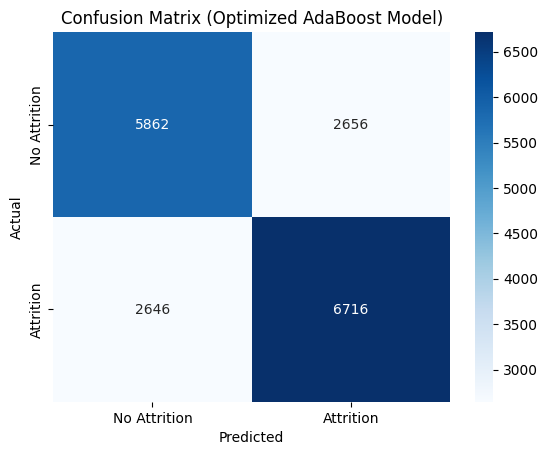

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.1

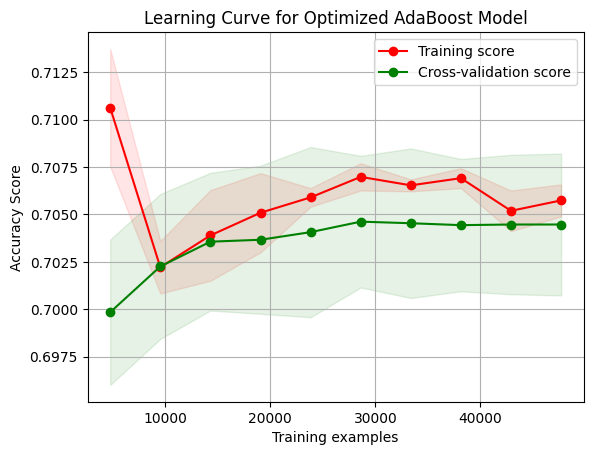

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data preparation
X = train.drop(columns=['Attrition'])
y = train['Attrition']

# Scaling features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Initialize AdaBoost with DecisionTreeClassifier as the base estimator
base_estimator = DecisionTreeClassifier(max_depth=1)
ada_boost = AdaBoostClassifier(estimator=base_estimator)

# Grid Search for Hyperparameter Tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
}

grid_search = GridSearchCV(estimator=ada_boost, param_grid=param_grid, scoring='accuracy', cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Print best parameters found
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# Initialize AdaBoost model with best parameters
ada_boost = AdaBoostClassifier(estimator=base_estimator, **best_params)

# Fit the AdaBoost model on the training set
ada_boost.fit(X_train, y_train)

# Making predictions
y_pred = ada_boost.predict(X_test)

# Generating and printing the classification report
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Attrition", "Attrition"], yticklabels=["No Attrition", "Attrition"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Optimized AdaBoost Model)")
plt.show()

# Generating learning curves
train_sizes, train_scores, test_scores = learning_curve(
    ada_boost, X, y, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculating mean and standard deviation for training and cross-validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plotting the learning curve
plt.figure()
plt.title("Learning Curve for Optimized AdaBoost Model")
plt.xlabel("Training examples")
plt.ylabel("Accuracy Score")
plt.grid()
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.legend(loc="best")
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Best parameters found:  {'learning_rate': 0.5, 'n_estimators': 100}


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.69      0.69      0.69      8518
           1       0.72      0.72      0.72      9362

    accuracy                           0.70     17880
   macro avg       0.70      0.70      0.70     17880
weighted avg       0.70      0.70      0.70     17880



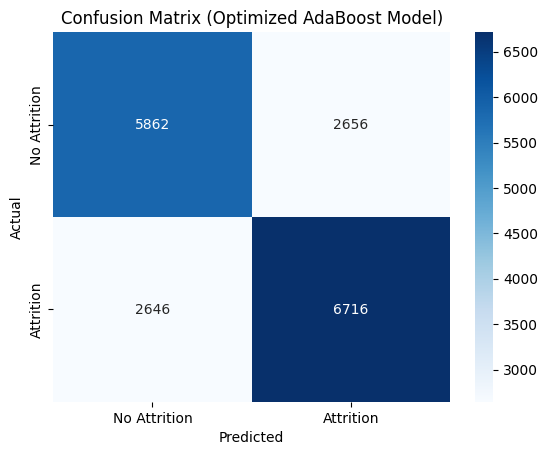

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.1

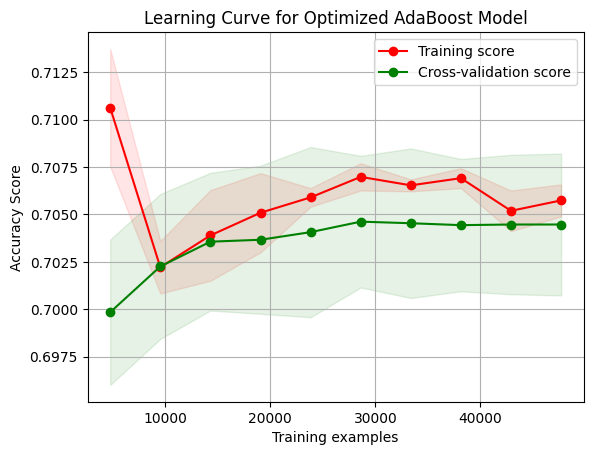

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data preparation
X = train.drop(columns=['Attrition'])
y = train['Attrition']

# Scaling features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Initialize AdaBoost with DecisionTreeClassifier as the base estimator
base_estimator = DecisionTreeClassifier(max_depth=1)
ada_boost = AdaBoostClassifier(estimator=base_estimator)

# Grid Search for Hyperparameter Tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
}

grid_search = GridSearchCV(estimator=ada_boost, param_grid=param_grid, scoring='accuracy', cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Print best parameters found
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# Initialize AdaBoost model with best parameters
ada_boost = AdaBoostClassifier(estimator=base_estimator, **best_params)

# Fit the AdaBoost model on the training set
ada_boost.fit(X_train, y_train)

# Making predictions
y_pred = ada_boost.predict(X_test)

# Generating and printing the classification report
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Attrition", "Attrition"], yticklabels=["No Attrition", "Attrition"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Optimized AdaBoost Model)")
plt.show()

# Generating learning curves
train_sizes, train_scores, test_scores = learning_curve(
    ada_boost, X, y, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculating mean and standard deviation for training and cross-validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plotting the learning curve
plt.figure()
plt.title("Learning Curve for Optimized AdaBoost Model")
plt.xlabel("Training examples")
plt.ylabel("Accuracy Score")
plt.grid()
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.legend(loc="best")
plt.show()




In [ ]:
!pip install catboost

# Import necessary libraries
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd

train = train.drop(columns=['Job Role', 'Marital Status', 'Employee ID'])
test = test.drop(columns=['Job Role', 'Marital Status', 'Employee ID'])

# Separate features and target variables from train and test datasets
X_train = train.drop(columns=['Attrition'])
y_train = train['Attrition']
X_test = test.drop(columns=['Attrition'])
y_test = test['Attrition']

# Define parameter grid for tuning
param_grid = {
    'iterations': [200, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 7],
    'bagging_temperature': [0, 1, 2, 3],
}

# Initialize the CatBoost model
cat_model = CatBoostClassifier(eval_metric='Accuracy', verbose=0)

# Set up RandomizedSearchCV for hyperparameter tuning
cat_random_search = RandomizedSearchCV(estimator=cat_model, param_distributions=param_grid,
                                       n_iter=20, scoring='accuracy', cv=3, random_state=42)

# Fit the randomized search model on training data
cat_random_search.fit(X_train, y_train)

# Retrieve best parameters
best_params = cat_random_search.best_params_
print("Best Parameters:", best_params)
print("Best Accuracy Score from CV:", cat_random_search.best_score_)

# Initialize CatBoost model with best parameters
optimized_cat_model = CatBoostClassifier(**best_params, eval_metric='Accuracy', verbose=100)

# Train the optimized model on the full training data
optimized_cat_model.fit(X_train, y_train)

# Predictions on test data
y_pred = optimized_cat_model.predict(X_test)

# Evaluate the model on the test set
print("Optimized Model Accuracy on Test Set:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 11.3 MB/s eta 0:00:00
Best Parameters: {'learning_rate': 0.01, 'l2_leaf_reg': 3, 'iterations': 800, 'depth': 8, 'bagging_temperature': 1}
Best Accuracy Score from CV: 0.7044699486559951
0:	learn: 0.6857613	total: 21.2ms	remaining: 16.9s
100:	learn: 0.7001074	total: 2.28s	remaining: 15.8s
200:	learn: 0.7069029	total: 4.54s	remaining: 13.5s
300:	learn: 0.7106279	total: 6.8s	remaining: 11.3s
400:	learn: 0.7127253	total: 10.8s	remaining: 10.7s
500:	learn: 0.7157623	total: 13.2s	remaining: 7.9s
600:	learn: 0.7184134	total: 15.5s	remaining: 5.12s
700:	learn: 0.7204436	total: 17.7s	remaining: 2.49s
799:	learn: 0.7226417	total: 19.8s	remaining: 0us
Optimized Model Accuracy on Test Set: 0.7036241610738255
              precision    recall  f1-score   support

           0       0.68      0.69      0.69      7032
           1       0.72      0.71      0.72      7868

    accuracy                           0.70     14900
   macro avg       

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 25008, number of negative: 22670
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012879 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 625
[LightGBM] [Info] Number of data points in the train set: 47678, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524519 -> initscore=0.098153
[LightGBM] [Info] Start training from score 0.098153
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 25008, number of negative: 22670
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004036 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_

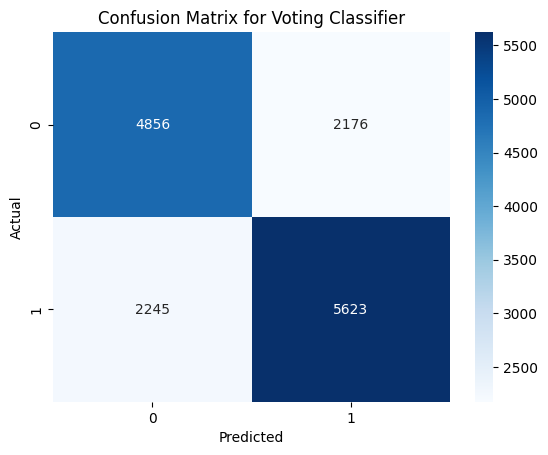

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Initialize individual models with optimized parameters
lightgbm_clf = lgb.LGBMClassifier(
    num_leaves=20,
    learning_rate=0.05,
    n_estimators=200,
    max_depth=15,
    min_child_samples=30,
    colsample_bytree=0.7,
    subsample=0.7
)

catboost_clf = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    verbose=0
)

adaboost_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # Updated to 'estimator'
    n_estimators=100,
    learning_rate=0.05
)

# Setting up the Voting Classifier
voting_clf = VotingClassifier(
    estimators=[
        ('lightgbm', lightgbm_clf),
        ('catboost', catboost_clf),
        ('adaboost', adaboost_clf)
    ],
    voting='soft'  # Use 'soft' for probability-based voting
)

# Train and evaluate with cross-validation on the training set
cv_scores = cross_val_score(voting_clf, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-validated accuracy:", cv_scores.mean())

# Fit the Voting Classifier on the entire training set
voting_clf.fit(X_train, y_train)

# Evaluate on the test set
y_pred = voting_clf.predict(X_test)

# Print the accuracy score and classification report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Optimized Voting Classifier Accuracy on Test Set:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Voting Classifier")
plt.show()


In [ ]:
!pip install optuna

import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X = train.drop(columns=['Attrition'])  # Replace 'Attrition' with the actual target column name if different
y = train['Attrition']

# Split data
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the objective function
def objective(trial):
    # Define the hyperparameter search space
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'random_strength': trial.suggest_uniform('random_strength', 1e-9, 10),
        'bagging_temperature': trial.suggest_uniform('bagging_temperature', 0, 10),
        'od_type': 'Iter',
        'od_wait': trial.suggest_int('od_wait', 10, 50),
        'logging_level': 'Silent'
    }

    # Initialize and train the CatBoost model with current parameters
    catboost_clf = CatBoostClassifier(**params, random_seed=42)
    catboost_clf.fit(X_train, y_train, eval_set=(X_valid, y_valid), early_stopping_rounds=50, verbose=0)

    # Make predictions and evaluate accuracy
    y_pred = catboost_clf.predict(X_valid)
    accuracy = accuracy_score(y_valid, y_pred)

    return accuracy

# Set up the Optuna study for optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)  # Adjust n_trials based on your computational resources

# Print the best parameters
print("Best parameters found: ", study.best_params)
print("Best accuracy score: ", study.best_value)


[I 2024-11-11 00:19:30,725] A new study created in memory with name: no-name-ba6090f9-f179-4e97-9513-b6cc6604f7fc
[I 2024-11-11 00:19:34,753] Trial 0 finished with value: 0.7019295302013423 and parameters: {'iterations': 376, 'depth': 7, 'learning_rate': 0.10899086006895004, 'l2_leaf_reg': 5.977647422557843, 'border_count': 87, 'random_strength': 3.164434996745559, 'bagging_temperature': 8.261496197279886, 'od_wait': 34}. Best is trial 0 with value: 0.7019295302013423.
[I 2024-11-11 00:19:39,091] Trial 1 finished with value: 0.7004194630872483 and parameters: {'iterations': 360, 'depth': 10, 'learning_rate': 0.07478680691910318, 'l2_leaf_reg': 6.096345998104216, 'border_count': 143, 'random_strength': 0.8730235942490571, 'bagging_temperature': 3.4615063803572954, 'od_wait': 20}. Best is trial 0 with value: 0.7019295302013423.
[I 2024-11-11 00:19:53,205] Trial 2 finished with value: 0.7041107382550336 and parameters: {'iterations': 973, 'depth': 5, 'learning_rate': 0.012456706097734782,

Best parameters found:  {'iterations': 751, 'depth': 4, 'learning_rate': 0.021244774077389037, 'l2_leaf_reg': 7.225408211898572, 'border_count': 137, 'random_strength': 3.0173623366567144, 'bagging_temperature': 2.616758408746249, 'od_wait': 40}
Best accuracy score:  0.7050335570469799
